# Moving Average (MA) Model 


## Prerequisites:

To start Moving Average (MA) model, you must have a proper understanding of a few basic concepts like:

- Time Series data  
- Autocovariance, Autocorrelation
- ACF, PACF plots


## Learning Objective:

- Understand the concept of Moving Average (MA) model, its mathematical notation and data generation process.

- Analyze PACF, ACF plots for MA(q) model.

- Apply MA(q) model on synthetic data using `statsmodels`.


The usual trend is that the shock events that occur today tend to affect the economic variable for some days in the future too. For example, today's event might affect the stock price not only today, but tomorrow and more days to come. In other words, the stock price may be affected by some past shock events. An example of such modelling is $ X_t = Z_t + 0.6 Z_{t - 1} + 0.4 Z_{t-2} + 0.2 Z_{t-3}$. Here, the more, the earlier the event is, the less it affects the current value. It's the assumption of the Moving Average (MA) model.  

Hence, in an MA model, the value of some variable $X$ at time $t$, $X_t$, is interpreted as the linear combination of the $q$ past values for $Z$, $Z_{t-1}, Z_{t-2}, Z_{t-3}, . . . ,Z_{t-q}$, plus some random noise. Here, $q$ is the number of time steps back, the model looks in the series. This value $q$ is called the order of the MA model.



## Mathematical Expression for MA(q) Model

>$
\begin{align*}
X_t 
&= Z_t + \theta_1 Z_{t-1} + \theta_2 Z_{t-2}+ .... + \theta_q Z_{t-q}  \\
&= Z_t + \sum_{i = 1} ^q {\theta_i Z_{t - i}}
\end{align*}
$

where,

* $θ_1, ..., θ_q$ are the model parameters. 

* $Z_t$ is white noise introduced at current time $t$.

* $q$ is the order of the MA model.



## Example 

Let's take the example of the MA(1) model we used earlier. 

$\quad \quad X_t = Z_t + 0.9 Z_{t - 1}$

This is a simple MA(1) model with a parameter $\theta_1 = 0.9$. We can represent this model as follows.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
ar_params = np.array([]) # kept empty to generate an AR model
ma_params = np.array([0.9]) # theta_1 = 0.9 

ar = np.r_[1, -ar_params] # stacking 1 allows to include X_t term
ma = np.r_[1, ma_params] # stacking 1 allows to include lag 0 in MA parameters  

Next, we build an MA process. We don't have  a separate function for MA process but one for ARMA process in `statsmodels`. Though we use `ArmaProcess` in the code, we have kept the `ar_params` empty to output an MA model. It'll be clear once we visit the ARMA model. For now, you can take this as a black box that outputs an MA process. 

After building the MA process, we then generate the time series data using the MA process. We do this as follows. 


In [ ]:
# build an MA process
ma_process = ArmaProcess(ar, ma) 

# generate some samples of time series data using the MA process 
X = ma_process.generate_sample(nsample=5000) 

### Time Series Plot


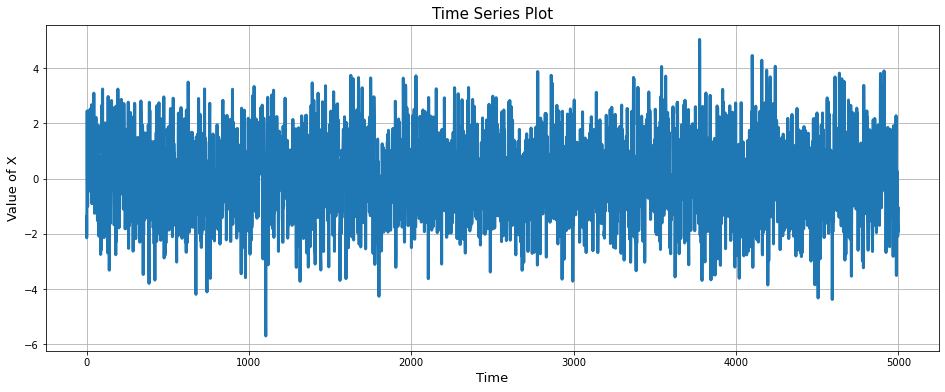

In [ ]:
def plot_series(X): 
    """ Plots the time series data X.

    Args:
        X (np.array): Time-series data
    """

    fig = plt.figure(figsize=(16, 6))
    plt.plot(X, linewidth=3)
    plt.title('Time Series Plot', fontsize=15)
    plt.xlabel('Time', fontsize=13)
    plt.ylabel('Value of X', fontsize=13)
    plt.grid()
    plt.show()
    
plot_series(X)

### ACF and PACF Plots


In [ ]:
def plot_graphs(X=None, ma_params=None, figsize=(10, 5), get_X=False):
    """ Plot ACF and PACF graphs
    
        Takes in time series data and plots the ACF and PACF graphs for the 
        series. When the time series is not provided, it generates the time 
        series using ma params and plots the graphs.

    Args:
        X (np.array): time series data
        ma_params (np.array): MA parameters - (theta1, theta2, ...)
        figsize (tuple): size for the figure

    """

    title = 'Autocorrelation for MA model ~ {}'.format(str(ma_params))

    # if X is None, create an ArmaProcess using the passed MA params and generate
    #  samples using the process
    if X is None:
        ma = np.r_[1, ma_params]
        ma_process = ArmaProcess(ar=[1], ma=ma)
        X = ma_process.generate_sample(nsample=10000)

    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(hspace=0.45)

    # ACF plot
    ax = fig.add_subplot(211)
    sm.graphics.tsa.plot_acf(X, ax=ax)
    ax.set_title(title, fontsize=14)

    # PACF plot
    ax = fig.add_subplot(212)
    sm.graphics.tsa.plot_pacf(X, ax=ax)
    ax.set_title('Partial ' + title, fontsize=14)

    plt.show()
    if get_X:
        return X

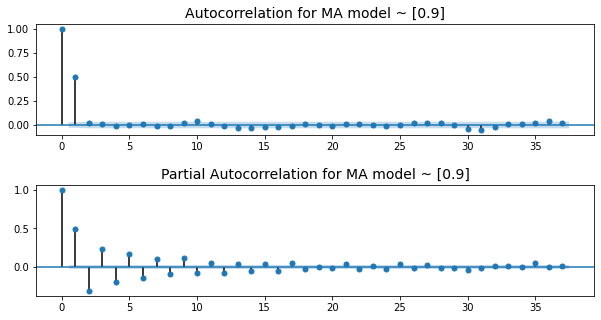

In [ ]:
plot_graphs(X=X, ma_params=ma_params)

When we observe the above figures for ACF and PACF for the MA(1) process, we can realize that the ACF values drop abruptly to about zero after lag one, whereas the PACF values cut off. **Does the ACF plot for the MA model have some link with the order of the model?**. Let's explore.


## Relation between Order and ACF Plot for MA Model

Let's explore with two MA models with order 2 and 3.

$
\quad \quad
{
    X_t = Z_t + 0.9 Z_{t-1} + 0.7 Z_{t-2} \\
    X_t = Z_t + 0.9 Z_{t-1} + 0.8 Z_{t-2} + 0.6 Z_{t-3}
}$


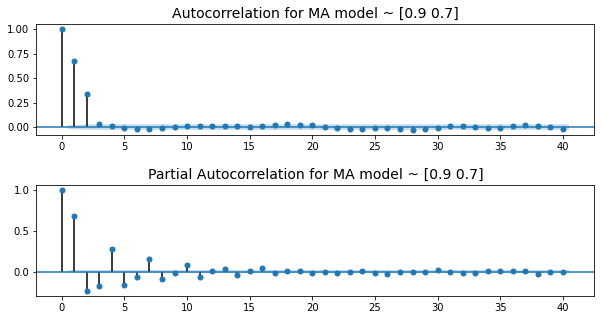

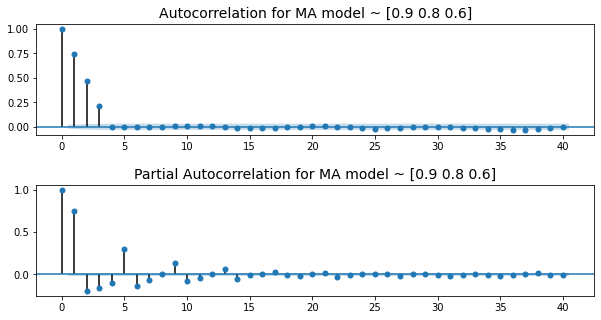

In [ ]:
# ma params for example models
ma_params1 = np.array([0.9, 0.7]) 
ma_params2 = np.array([0.9, 0.8, 0.6]) 

# plotting ACF and PACF graphs 
plot_graphs(ma_params=ma_params1)
X_3 = plot_graphs(ma_params=ma_params2, get_X = True)

### **Observation**

From the above experimentation, ACF values drop significantly after 2 and 3 lags for MA(2) and MA(3) models. It looks like the **ACF values for MA(q) model drop abruptly to zero after the q lags**. It's the case actually, and we can prove it. However, the proof is out of the scope of this reading material.

Well, **how can we leverage this information, we just obtained?**

The thing is that we get some real-world time series data on which we need to fit models. We don't know anything about the underlying data generation process. To leverage the information we got here, we can plot the ACF and PACF for the time series data. And if the plots follow the nature `(PACF drops tail off but ACF drops abruptly to zero after some lags)` we saw earlier, we can know the order of the MA model we need to fit on, and the next part will be to fit the MA model.





## Fitting MA(q) Model

Let's use the data `X_3` we generated for MA(3): $X_t = Z_t + 0.9 Z_{t-1} + 0.8 Z_{t-2} + 0.6 Z_{t-3}$ model before. We know that the underlying data generation process is an MA process of order 3 for this dataset. However, for real-world datasets, we don't know the data generation process in advance. Hence, we should plot ACF and PACF graphs for the data, and as said earlier, if the plots follow the nature we discussed earlier, we can fit an MA model of the predicted order. Otherwise, we need to resort to other models.

We will avoid the pre-step for the synthetic dataset `X_3` since we have already watched the ACF and PACF plots already. As we know, the order is 3; we'll show how the model can be fitted using `statsmodels`.


In [ ]:
ar_order = 0 # fitting dataset from MA(3) process so order is 0 for ar_part
ma_order = 3 # fitting dataset from MA(3) process so order is 3 for ma_part
order = (ar_order, ma_order)

# create an instance of `ARMA` model of the required order with the data and the 
# order and use the `fit` method to fit the model on the data
ma_model = sm.tsa.ARMA(X_3, order=order).fit(trend='nc', disp=-1)
ma_model.params

array([0.50068289, 0.29081155])

The `ma_params` for the data generation process, $X_t = Z_t + 0.9 Z_{t-1} + 0.8 Z_{t-2} + 0.6 Z_{t-3}$, was $(0.9, 0.8, 0.6)$. The parameters of the fitted model, printed above, are near to these values.


## Key Takeaways

1. In the MA(q) model, $X_t$ is taken as the linear combination of the $q$ past noise values $(Z_{t-1}, Z_{t-2}, Z_{t-3}, . . . ,Z_{t-q})$, plus some random noise at time t $(Z_t)$.

2. For MA(q) models, ACF values drop abruptly to about zero after lag p, whereas the PACF values tail off.


## References

- Shumway R., Stoffer D. (2016) Time Series Analysis and Its Applications: With R Examples, 4th edition, Springer
    * Check definition 3.3 in page 83 for more information on autoregressive model.
